# Memory Management in langGraph

In [1]:
import json
import warnings
from typing import Any, Literal

import numpy as np
import pandas as pd
import polars as pl
from rich.console import Console
from rich.theme import Theme

custom_theme = Theme(
    {
        "white": "#FFFFFF",  # Bright white
        "info": "#00FF00",  # Bright green
        "warning": "#FFD700",  # Bright gold
        "error": "#FF1493",  # Deep pink
        "success": "#00FFFF",  # Cyan
        "highlight": "#FF4500",  # Orange-red
    }
)
console = Console(theme=custom_theme)

# Visualization
# import matplotlib.pyplot as plt

# NumPy settings
np.set_printoptions(precision=4)

# Pandas settings
pd.options.display.max_rows = 1_000
pd.options.display.max_columns = 1_000
pd.options.display.max_colwidth = 600

# Polars settings
pl.Config.set_fmt_str_lengths(1_000)
pl.Config.set_tbl_cols(n=1_000)
pl.Config.set_tbl_rows(n=200)

warnings.filterwarnings("ignore")

# Black code formatter (Optional)
%load_ext lab_black

# auto reload imports
%load_ext autoreload
%autoreload 2

In [2]:
def go_up_from_current_directory(*, go_up: int = 1) -> None:
    """This is used to up a number of directories.

    Params:
    -------
    go_up: int, default=1
        This indicates the number of times to go back up from the current directory.

    Returns:
    --------
    None
    """
    import os
    import sys

    CONST: str = "../"
    NUM: str = CONST * go_up

    # Goto the previous directory
    prev_directory = os.path.join(os.path.dirname(__name__), NUM)
    # Get the 'absolute path' of the previous directory
    abs_path_prev_directory = os.path.abspath(prev_directory)

    # Add the path to the System paths
    sys.path.insert(0, abs_path_prev_directory)
    print(abs_path_prev_directory)


# Demo (Prevents ruff from removing the unused module import)
name: Any
category: Literal["A", "B", "C"]
json.loads('{"name": "Bike Rental Prediction", "category": "A"}')

{'name': 'Bike Rental Prediction', 'category': 'A'}

In [3]:
go_up_from_current_directory(go_up=2)

from model_config import LocalModel, RemoteModel  # noqa: E402
from settings import refresh_settings  # noqa: E402

settings = refresh_settings()

/Users/mac/Desktop/Projects/RAG-Tutorials


In [4]:
from langchain_openai import ChatOpenAI

remote_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=RemoteModel.X_AI_GROK_4_FAST,
)

# Test the LLMs
response = remote_llm.invoke("Tell me a very short joke.")
response.pretty_print()

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


================================== Ai Message ==================================

Why don't scientists trust atoms? Because they make up everything!


<br><hr>

# Short-term memory
​
### Overview

- Memory is a system that remembers information about previous interactions. For AI agents, memory is crucial because it lets them remember previous interactions, learn from feedback, and adapt to user preferences. As agents tackle more complex tasks with numerous user interactions, this capability becomes essential for both efficiency and user satisfaction.

- Short term memory lets your application remember previous interactions within a single thread or conversation.

- Long conversations pose a challenge to today’s LLMs; a full history may not fit inside an LLM’s context window, resulting in an context loss or errors.

- Even if your model supports the full context length, most LLMs still perform poorly over long contexts. They get “distracted” by stale or off-topic content, all while suffering from slower response times and higher costs.

- Chat models accept context using messages, which include instructions (a system message) and inputs (human messages). In chat applications, messages alternate between human inputs and model responses, resulting in a list of messages that grows longer over time. Because context windows are limited, many applications can benefit from using techniques to remove or “forget” stale information.

In [5]:
from typing import Annotated, TypedDict

from langchain_core.messages import (
    AIMessage,
    AnyMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.tools import tool
from langgraph.graph.message import add_messages

In [6]:
from IPython.display import Image, Markdown, display
from langchain.messages import RemoveMessage
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph

In [7]:
from datetime import datetime

chatbot_system_message: str = """
<SYSTEM>
    <ROLE>You are a knowledgeable and helpful chatbot assistant.</ROLE>

    <GUIDELINES>
    - Provide clear, accurate, and contextually relevant answers based on the user's input.
    - Keep responses focused, concise, and directly related to the conversation.
    - If information is insufficient, politely ask for clarification.
    - Limit responses to a maximum of five sentences.
    </GUIDELINES>
</SYSTEM>
"""

query_prompt: str = """
<USER>
    <QUERY>{query}</QUERY>
</USER>
"""

summary_prompt: str = """
<USER>
    <GUIDELINES>
        - Expand the summary by incorporating the the above conversation while preserving context, key points, and
        user intent. 
        - Rework the summary if needed. Ensure that no critical information is lost and that the 
        conversation can continue naturally without gaps. 
        - Keep the summary concise yet informative, removing unnecessary repetition while maintaining clarity.
        - Only return the updated summary. Do not add explanations, section headers, or extra commentary.
    </GUIDELINES>

    <SUMMARY>{summary}</SUMMARY>

</USER>
"""

no_summary_prompt: str = """
<USER>
    <GUIDELINES>
    - Summarize the conversation above while preserving full context, key points, and user intent. 
    - Your response should be concise yet detailed enough to ensure seamless continuation of the discussion.
    - Avoid redundancy, maintain clarity, and retain all necessary details for future exchanges.
    - Only return the summarized content. Do not add explanations, section headers, or extra commentary.
    </GUIDELINES>

</USER>
"""

In [8]:
from langchain_community.tools import DuckDuckGoSearchResults
import httpx
from markdownify import markdownify


async def afetch_raw_content(url: str) -> str | None:
    """
    Asynchronously fetch HTML content from a URL and convert it to markdown format.

    Parameters
    ----------
    url : str
        The URL to fetch content from.

    Returns
    -------
    str or None
        The fetched content converted to markdown if successful,
        None if any error occurs during fetching or conversion.

    Notes
    -----
    Uses a 10-second timeout to avoid hanging on slow sites or large pages.
    """
    try:
        # Create a client with reasonable timeout
        async with httpx.AsyncClient() as client:
            response = await client.get(url, timeout=10)
            response.raise_for_status()
            return markdownify(response.text)
    except Exception as e:
        print(f"Warning: Failed to fetch full page content for {url}: {str(e)}")
        return None


# await afetch_raw_content(url)
async def duckduckgo_search(
    query: str, fetch_full_page: bool = False
) -> dict[str, list[dict[str, Any]]]:
    try:
        search = DuckDuckGoSearchResults(output_format="list", num_results=6)
        raw_results = await search.ainvoke(query)

        # format the data
        raw_results: list[dict[str, Any]] = [
            {
                "title": row["title"],
                "url": row["link"],
                "content": row["snippet"],
                "raw_content": row["snippet"],
            }
            for row in raw_results
        ]

        if fetch_full_page:
            raw_results = [
                {
                    **row,
                    **{
                        "raw_content": await afetch_raw_content(row["url"]),
                    },
                }
                for row in raw_results
            ]
        return {"results": raw_results}

    except Exception as e:
        print(f"Duckduckgo search failed: {str(e)}")
        return {"results": []}

In [9]:
res = await duckduckgo_search(query="Who is Adrej Karpathy?", fetch_full_page=True)

In [10]:
res

{'results': [{'title': 'Wikipedia Andrej Karpathy - Wikipedia',
   'url': 'https://en.wikipedia.org/wiki/Andrej_Karpathy',
   'content': '1 week ago - Andrej Karpathy (born 23 October 1986) is a Slovak-Canadian computer scientist who served as the director of artificial intelligence and Autopilot Vision at Tesla.',
   'raw_content': 'Andrej Karpathy - Wikipedia\n\n[Jump to content](#bodyContent)\n\nMain menu\n\nMain menu\n\nmove to sidebar\nhide\n\nNavigation\n\n* [Main page](/wiki/Main_Page "Visit the main page [z]")\n* [Contents](/wiki/Wikipedia:Contents "Guides to browsing Wikipedia")\n* [Current events](/wiki/Portal:Current_events "Articles related to current events")\n* [Random article](/wiki/Special:Random "Visit a randomly selected article [x]")\n* [About Wikipedia](/wiki/Wikipedia:About "Learn about Wikipedia and how it works")\n* [Contact us](//en.wikipedia.org/wiki/Wikipedia:Contact_us "How to contact Wikipedia")\n\nContribute\n\n* [Help](/wiki/Help:Contents "Guidance on how 

In [11]:
def format_search_results(
    data: dict[str, list[dict[str, Any]]], max_char: int = 500
) -> str:
    formatted_res: str = "\n\n==========\n\n".join(
        [
            f"[title]: {row['title']}\n[url]: {row['url']}\n[content]: {row['content']}"
            f"\n[raw_content]: {row['raw_content'][:max_char]} </truncated>\n"
            for row in data["results"]
        ]
    ).strip()
    return formatted_res

In [12]:
import calendar


def day_name_tool(year: int, month: int, day: int) -> str:
    """Determine the name of the day for a given date.
    Parameters
    ----------
    year : int
        The year for which to generate the calendar (e.g., 2025).
    month : int
        The month for which to generate the calendar (1-12).
    day : int
        The day of the month (not used in calendar generation).

    Returns
    -------
    str
        The name of the day for the given date.
    """
    if not isinstance(year, int) or year < 1:
        raise ValueError("Year must be a positive integer.")
    if not isinstance(month, int):
        raise ValueError("Month must be an integer.")
    if not isinstance(day, int):
        raise ValueError("Day must be an integer.")
    if not (1 <= month <= 12):
        raise ValueError("Month must be between 1 and 12.")
    if not (1 <= day <= 31):
        raise ValueError("Day must be between 1 and 31.")

    return calendar.day_name[calendar.weekday(year, month, day)]


@tool(response_format="content")
def date_and_time_tool() -> str:
    """
    Get the current date, time, and day name as a string.

    Returns
    -------
    str
        The current date, time, and day name as a string.
    """
    raw_date: str = datetime.now().isoformat()
    date: str = raw_date.split("T")[0]
    time: str = raw_date.split("T")[-1]

    day_name: str = day_name_tool(
        year=int(date.split("-")[0]),
        month=int(date.split("-")[1]),
        day=int(date.split("-")[2]),
    )

    return f"Date: {date}\n\nTime: {time} (GMT+1)\n\nDay Name: {day_name}"


@tool(response_format="content")
async def search_tool(query: str, fetch_full_page: bool = False) -> str:
    """Perform a web search using DuckDuckGo and format the results.

    This tool queries DuckDuckGo for search results, optionally fetching full page content,
    and returns the formatted results as a string.

    Parameters
    ----------
    query : str
        The search query string to look up.
    fetch_full_page : bool, default=False
        Whether to fetch the full page content for each search result.

    Returns
    -------
    str
        Formatted search results including titles, URLs, snippets, and optionally full content.
    """
    results = await duckduckgo_search(query, fetch_full_page=fetch_full_page)
    return format_search_results(results)

In [13]:
print(date_and_time_tool.func())

Date: 2025-10-28

Time: 22:03:36.437145 (GMT+1)

Day Name: Tuesday


### Remove Messages

In [14]:
existing_msgs = [
    HumanMessage(content="Message 1", id=1),
    AIMessage(content="Message 2", id=2),
    HumanMessage(content="Message 3", id=3),
    AIMessage(
        content="Message 4",
        id=4,
    ),
    HumanMessage(content="Message 5", id=5),
]

new_messages = [
    AIMessage(
        content="Message 6",
        id=6,
    ),
    HumanMessage(content="Message 7", id=7),
    AIMessage(content="Message 8", id=8),
]

messages = add_messages(existing_msgs, new_messages)
messages

[HumanMessage(content='Message 1', additional_kwargs={}, response_metadata={}, id='1'),
 AIMessage(content='Message 2', additional_kwargs={}, response_metadata={}, id='2'),
 HumanMessage(content='Message 3', additional_kwargs={}, response_metadata={}, id='3'),
 AIMessage(content='Message 4', additional_kwargs={}, response_metadata={}, id='4'),
 HumanMessage(content='Message 5', additional_kwargs={}, response_metadata={}, id='5'),
 AIMessage(content='Message 6', additional_kwargs={}, response_metadata={}, id='6'),
 HumanMessage(content='Message 7', additional_kwargs={}, response_metadata={}, id='7'),
 AIMessage(content='Message 8', additional_kwargs={}, response_metadata={}, id='8')]

In [15]:
# Remove messages except the last 2
messages_to_remove = [RemoveMessage(id=m.id) for m in messages[:-2]]
messages_to_remove

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='1'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='2'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='3'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='4'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='5'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='6')]

In [16]:
updated_messages = add_messages(messages, messages_to_remove)
updated_messages

[HumanMessage(content='Message 7', additional_kwargs={}, response_metadata={}, id='7'),
 AIMessage(content='Message 8', additional_kwargs={}, response_metadata={}, id='8')]

### Create A Simple Graph

In [17]:
# ===============================================================
# =========================== STATES ============================
# ===============================================================
class State(TypedDict):
    query: str
    response: str
    messages: Annotated[list[Any], add_messages]
    summary: str


# ===============================================================
# ============================ LLMS =============================
# ===============================================================
MAX_SUMMARY_TOKENS: int = 1024
MAX_MESSAGES: int = 6

llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=RemoteModel.GPT_OSS_20B,
)
summarization_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=RemoteModel.QWEN3_30B_A3B,
).bind(max_tokens=MAX_SUMMARY_TOKENS)


# ===============================================================
# ============================ NODES ============================
# ===============================================================
async def llm_with_no_tools(state: State) -> State:
    summary: str = state.get("summary", "")
    sys_msg = SystemMessage(content=chatbot_system_message)

    if summary:
        summary_msg = SystemMessage(content=f"Summary of conversation:\n\n {summary}")
        # Summary + most recent messages
        msgs_with_summary = [summary_msg] + state["messages"]

    else:
        msgs_with_summary = state["messages"]

    _msg = query_prompt.format(query=state.get("query", ""))
    query = HumanMessage(content=_msg)
    response = await llm.ainvoke([sys_msg] + msgs_with_summary + [query])

    return State(
        query=state.get("query", ""),
        response=response.content,
        messages=[state.get("query", ""), response],
        summary=summary,
    )


async def summarization_node(state: State) -> State:
    summary: str = state.get("summary", "")

    if summary:
        summary_msg: list[AnyMessage] = [
            HumanMessage(content=summary_prompt.format(summary=summary))
        ]
    else:
        summary_msg = [HumanMessage(content=no_summary_prompt)]

    response: AIMessage = await summarization_llm.ainvoke(
        state["messages"] + summary_msg
    )

    # Delete ALL but the last 2 messages
    messages_to_remove = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]

    return State(
        query=state.get("query", None),
        response=state.get("response", None),
        messages=messages_to_remove,
        summary=response.content,
    )


# ===============================================================
# =========================== EDGEs =============================
# ===============================================================
def should_summarize(state: State) -> Literal["summarize", END]:
    if len(state["messages"]) > MAX_MESSAGES:
        return "summarize"

    return END

In [18]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import RetryPolicy

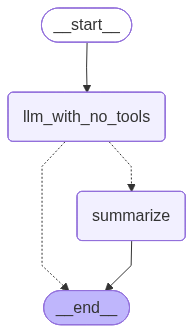

In [19]:
max_attempts: int = 2

# Memory
memory = MemorySaver()
builder = StateGraph(State)

# Add Nodes
builder.add_node(
    "llm_with_no_tools",
    llm_with_no_tools,
    retry_policy=RetryPolicy(max_attempts=max_attempts, initial_interval=1.0),
)
builder.add_node(
    "summarize",
    summarization_node,
    retry_policy=RetryPolicy(max_attempts=max_attempts, initial_interval=1.0),
)

# Add Edges
builder.add_edge(START, "llm_with_no_tools")
builder.add_conditional_edges(
    "llm_with_no_tools", should_summarize, {"summarize": "summarize", END: END}
)

# Build the graph
graph = builder.compile(checkpointer=memory)


# Visualize the graph with ASCII fallback
try:
    display(Image(graph.get_graph(xray=1).draw_mermaid_png()))
except Exception as e:
    console.print(f"[yellow]PNG visualization failed: {e}[/yellow]")
    console.print("[cyan]Displaying ASCII representation instead:[/cyan]\n")
    try:
        print(graph.get_graph(xray=1).draw_ascii())
    except ImportError as ie:
        console.print(f"[red]ASCII visualization also failed: {ie}[/red]")
        console.print("[magenta]Showing basic graph structure:[/magenta]\n")
        graph_obj = graph.get_graph(xray=1)
        console.print(f"Nodes: {[node.id for node in graph_obj.nodes.values()]}")
        console.print(f"Edges: {[(e.source, e.target) for e in graph_obj.edges]}")

In [20]:
config: dict[str, Any] = {"configurable": {"thread_id": "1"}}

response = await graph.ainvoke(
    {"query": "Hi, I'm Segun. Tell me a very short joke."},
    config=config,
)

response

{'query': "Hi, I'm Segun. Tell me a very short joke.",
 'response': 'Sure thing, Segun—why did the scarecrow win an award? Because he was outstanding in his field!',
 'messages': [HumanMessage(content="Hi, I'm Segun. Tell me a very short joke.", additional_kwargs={}, response_metadata={}, id='47592239-a35a-4f62-8cb5-f79ac2dce451'),
  AIMessage(content='Sure thing, Segun—why did the scarecrow win an award? Because he was outstanding in his field!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 188, 'total_tokens': 250, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': None, 'id': 'gen-1761685418-x1EEHYOU4g7DRlSq4K3l', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--52314fb8-1725-41f2-a479-3ec28bb571b2-0', usage_metadata={'input_tokens': 188, 'output_tokens': 62, 'total_tokens': 250, 'input_token_details': {}, '

In [21]:
response = await graph.ainvoke(
    {"query": "Tell me another short joke."},
    config=config,
)

response

{'query': 'Tell me another short joke.',
 'response': 'Why don’t skeletons fight each other? They don’t have the guts.',
 'messages': [HumanMessage(content="Hi, I'm Segun. Tell me a very short joke.", additional_kwargs={}, response_metadata={}, id='47592239-a35a-4f62-8cb5-f79ac2dce451'),
  AIMessage(content='Sure thing, Segun—why did the scarecrow win an award? Because he was outstanding in his field!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 188, 'total_tokens': 250, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': None, 'id': 'gen-1761685418-x1EEHYOU4g7DRlSq4K3l', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--52314fb8-1725-41f2-a479-3ec28bb571b2-0', usage_metadata={'input_tokens': 188, 'output_tokens': 62, 'total_tokens': 250, 'input_token_details': {}, 'output_token_details': {}}),
  HumanMessage(c

In [22]:
response = await graph.ainvoke(
    {"query": "What do you know about Andrej Karpathy?"},
    config=config,
)

response

{'query': 'What do you know about Andrej Karpathy?',
 'response': 'Andrej\u202fKarpathy is a prominent computer‑learning researcher and engineer. He earned a Ph.D. in computer vision from Stanford (under Fei‑Fei\u202fLi) and was a key member of the ImageNet team that helped spark the deep‑learning revolution. Karpathy has worked at OpenAI, where he led the GPT‑2 project, and later joined Tesla as Director of AI, overseeing the company’s self‑driving vision stack. He’s known for his clear, accessible explanations of neural networks, his popular “Neural Networks and Deep Learning” online course, and his influential talks on AI safety and ethics. As of 2024, he remains a leading voice in AI research and a frequent speaker at conferences and in media.',
 'messages': [HumanMessage(content="Hi, I'm Segun. Tell me a very short joke.", additional_kwargs={}, response_metadata={}, id='47592239-a35a-4f62-8cb5-f79ac2dce451'),
  AIMessage(content='Sure thing, Segun—why did the scarecrow win an awar

In [23]:
len(response["messages"])

6

In [24]:
response = await graph.ainvoke(
    {"query": "What's my name?"},
    config=config,
)

response

{'query': "What's my name?",
 'response': 'Your name is Segun.',
 'messages': [HumanMessage(content="What's my name?", additional_kwargs={}, response_metadata={}, id='32ab3ee3-7463-402c-a69b-5b2470175bfb'),
  AIMessage(content='Your name is Segun.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 429, 'total_tokens': 467, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': None, 'id': 'gen-1761685422-rLPoYPS0eOLSboLWTvgc', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--a4d2f116-8db9-420c-9ff4-418e95e0cf3f-0', usage_metadata={'input_tokens': 429, 'output_tokens': 38, 'total_tokens': 467, 'input_token_details': {}, 'output_token_details': {}})],
 'summary': "User introduced themselves as Segun, requested two short jokes, asked about Andrej Karpathy's background, and confirmed their name. The conversation included a

In [25]:
response = await graph.ainvoke(
    {"query": "What's the current time?"},
    config=config,
)

response

{'query': "What's the current time?",
 'response': 'I’m not connected to a real‑time clock, so I can’t tell you the exact current time. If you’re on a computer or phone, you can check the clock widget or ask your device’s voice assistant for the time.',
 'messages': [HumanMessage(content="What's my name?", additional_kwargs={}, response_metadata={}, id='32ab3ee3-7463-402c-a69b-5b2470175bfb'),
  AIMessage(content='Your name is Segun.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 429, 'total_tokens': 467, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': None, 'id': 'gen-1761685422-rLPoYPS0eOLSboLWTvgc', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--a4d2f116-8db9-420c-9ff4-418e95e0cf3f-0', usage_metadata={'input_tokens': 429, 'output_tokens': 38, 'total_tokens': 467, 'input_token_details': {}, 'output_token_

In [26]:
len(response["messages"])

4

<br>

### Add Tools

In [27]:
chatbot_system_message: str = """
<SYSTEM>
    <ROLE>You are a knowledgeable and helpful chatbot assistant.</ROLE>

    <GUIDELINES>
    - Provide clear, accurate, and contextually relevant answers based on the user's input.
    - Use available tools to ensure responses are current and reliable.
    - Keep responses focused, concise, and directly related to the conversation.
    - If information is insufficient, politely ask for clarification.
    - Limit responses to a maximum of five sentences.
    </GUIDELINES>
</SYSTEM>
"""


async def llm_with_tools_node(state: State) -> State:
    summary: str = state.get("summary", "")
    sys_msg = SystemMessage(content=chatbot_system_message)

    if summary:
        summary_msg = SystemMessage(content=f"Summary of conversation:\n\n {summary}")
        # Summary + most recent messages
        msgs_with_summary = [summary_msg] + state["messages"]

    else:
        msgs_with_summary = state["messages"]

    _msg = query_prompt.format(query=state.get("query", ""))
    query = HumanMessage(content=_msg)
    llm_with_tools = llm.bind_tools([search_tool, date_and_time_tool])
    response = await llm_with_tools.ainvoke([sys_msg] + msgs_with_summary + [query])

    return State(
        query=state.get("query", ""),
        response=response.content,
        messages=[state.get("query", ""), response],
        summary=summary,
    )

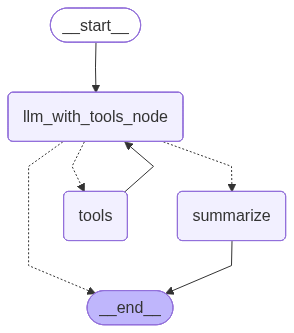

In [28]:
max_attempts: int = 2

# Memory
memory = MemorySaver()
tool_node = ToolNode([search_tool, date_and_time_tool])
builder = StateGraph(State)

# Add Nodes
builder.add_node(
    "llm_with_tools_node",
    llm_with_tools_node,
    retry_policy=RetryPolicy(max_attempts=max_attempts, initial_interval=1.0),
)
builder.add_node(
    "summarize",
    summarization_node,
    retry_policy=RetryPolicy(max_attempts=max_attempts, initial_interval=1.0),
)
builder.add_node(
    "tools",
    tool_node,
    retry_policy=RetryPolicy(max_attempts=max_attempts, initial_interval=1.0),
)

# Add Edges
# builder.add_c
builder.add_edge(START, "llm_with_tools_node")
builder.add_conditional_edges(
    "llm_with_tools_node", tools_condition, {"tools": "tools", END: END}
)
builder.add_conditional_edges(
    "llm_with_tools_node", should_summarize, {"summarize": "summarize", END: END}
)
builder.add_edge("tools", "llm_with_tools_node")


# Build the graph
graph = builder.compile(checkpointer=memory)


# Visualize the graph with ASCII fallback
try:
    display(Image(graph.get_graph(xray=1).draw_mermaid_png()))
except Exception as e:
    console.print(f"[yellow]PNG visualization failed: {e}[/yellow]")
    console.print("[cyan]Displaying ASCII representation instead:[/cyan]\n")
    try:
        print(graph.get_graph(xray=1).draw_ascii())
    except ImportError as ie:
        console.print(f"[red]ASCII visualization also failed: {ie}[/red]")
        console.print("[magenta]Showing basic graph structure:[/magenta]\n")
        graph_obj = graph.get_graph(xray=1)
        console.print(f"Nodes: {[node.id for node in graph_obj.nodes.values()]}")
        console.print(f"Edges: {[(e.source, e.target) for e in graph_obj.edges]}")

In [29]:
# Build the graph
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

config: dict[str, Any] = {"configurable": {"thread_id": "1"}}
response = await graph.ainvoke(
    {"query": "Hi, I'm Segun. Tell me a very short joke."},
    config=config,
)

response

{'query': "Hi, I'm Segun. Tell me a very short joke.",
 'response': 'Hey Segun, why did the scarecrow win an award? Because he was outstanding in his field! 😄',
 'messages': [HumanMessage(content="Hi, I'm Segun. Tell me a very short joke.", additional_kwargs={}, response_metadata={}, id='18bf7a16-d14f-42b2-851e-d7d826e9168f'),
  AIMessage(content='Hey Segun, why did the scarecrow win an award? Because he was outstanding in his field! 😄', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 425, 'total_tokens': 482, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 25, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_feb9b278f1', 'id': 'gen-1761685428-mwTFhA8Q6DJdZAHGlGHK', 'finish_reason': 'stop', 'logprobs': None}, id='l

In [30]:
response = await graph.ainvoke(
    {"query": "Who is the current Pope?"},
    config=config,
)

response

{'query': 'Who is the current Pope?',
 'response': 'The current pope is Pope\u202fLeo\u202fXIV (Robert Francis Prevost), who was elected on 8\u202fMay\u202f2025.',
 'messages': [HumanMessage(content='Who is the current Pope?', additional_kwargs={}, response_metadata={}, id='88f9abd5-8476-494c-9967-19193929cf43'),
  AIMessage(content='The current pope is Pope\u202fLeo\u202fXIV (Robert Francis Prevost), who was elected on 8\u202fMay\u202f2025.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 1547, 'total_tokens': 1608, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 24, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_a4315eb300', 'id': 'gen-1761685430-WHatMr9gaxtqcCdRNcAq', 'finish_reason': 'stop', 'logprobs': None

In [31]:
response = await graph.ainvoke(
    {"query": "Is today Monday?"},
    config=config,
)

response

{'query': 'Is today Monday?',
 'response': 'No, today is Tuesday.',
 'messages': [HumanMessage(content='Is today Monday?', additional_kwargs={}, response_metadata={}, id='65ab84db-94e0-4a2b-8444-1b254b8663dd'),
  AIMessage(content='No, today is Tuesday.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 607, 'total_tokens': 648, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 26, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_a4315eb300', 'id': 'gen-1761685436-EBDRRApG5L4QQjjxpB7q', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--529bd3b3-3171-469d-9027-11dc75252e89-0', usage_metadata={'input_tokens': 607, 'output_tokens': 41, 'total_tokens': 648, 'input_token_details': {'cache_read': 256}, 'output_token_d

In [32]:
response = await graph.ainvoke(
    {"query": "How do you know that?"},
    config=config,
)

response

{'query': 'How do you know that?',
 'response': 'I used the built‑in date and time tool, which returns the current day of the week along with the date and time. It reports that today is “Tuesday.” This tool is reliable and always up‑to‑date, so I can confirm the day with confidence.',
 'messages': [HumanMessage(content='How do you know that?', additional_kwargs={}, response_metadata={}, id='fff529fa-20c0-4910-8b02-0bb30e42e0b1'),
  AIMessage(content='I used the built‑in date and time tool, which returns the current day of the week along with the date and time. It reports that today is “Tuesday.” This tool is reliable and always up‑to‑date, so I can confirm the day with confidence.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 105, 'prompt_tokens': 588, 'total_tokens': 693, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 41, 'rejected_prediction_tokens': None}, 'prompt_tokens_det

In [33]:
len(response["messages"])

2

In [34]:
response = await graph.ainvoke(
    {
        "query": "What do you know about Andrej Karpathy? What are the current news about him?"
    },
    config=config,
)

response

{'query': 'What do you know about Andrej Karpathy? What are the current news about him?',
 'response': 'Andrej\u202fKarpathy is a prominent AI researcher who was a co‑founder of OpenAI, a senior AI director at Tesla, and a professor‑researcher at Stanford.  In 2025 he has moved to a new venture called\u202fEureka\u202fLabs, where he heads AI research and product development.  He recently open‑source‑d a lightweight ChatGPT‑style stack called **nanochat** (Oct\u202f14\u202f2025) to make large‑language‑model training more accessible.  In interviews he reiterated that true AGI is still roughly a decade away, and has been active on X, sharing insights on AI agents and emerging emotional‑recognition projects.  The term “vibe coding,” an AI‑assisted coding style he popularised in early\u202f2025, was even added to the Merriam‑Webster dictionary that same year.',
 'messages': [HumanMessage(content='What do you know about Andrej Karpathy? What are the current news about him?', additional_kwarg

In [35]:
# Because the context is too small and the number of messages to retain is also small, it has forgotten previous context
response = await graph.ainvoke(
    {
        "query": "What's my name? Who won the English Premier League last season (2024-2025)?"
    },
    config=config,
)

response

{'query': "What's my name? Who won the English Premier League last season (2024-2025)?",
 'response': 'I’m sorry—I don’t have your name on record. Could you let me know how you’d like to be addressed?  \nLiverpool FC were crowned champions of the 2024‑25 English Premier League, securing their 20th top‑flight title.',
 'messages': [HumanMessage(content="What's my name? Who won the English Premier League last season (2024-2025)?", additional_kwargs={}, response_metadata={}, id='c121d237-c85a-4e43-b20a-a381f5d5dda0'),
  AIMessage(content='I’m sorry—I don’t have your name on record. Could you let me know how you’d like to be addressed?  \nLiverpool FC were crowned champions of the 2024‑25 English Premier League, securing their 20th top‑flight title.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 133, 'prompt_tokens': 1668, 'total_tokens': 1801, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_